## 1. Import Libraries
All required libraries for data processing, visualization, and machine learning.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import joblib
import sys
sys.path.insert(0, '../src')
from utils import clean_text
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\redea\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

##  2. Load Dataset
Load Fake.csv and True.csv, assign labels (0 = Fake, 1 = Real), merge and shuffle.

In [4]:
fake_df = pd.read_csv('../data/Fake.csv')
true_df = pd.read_csv('../data/True.csv')

fake_df['label'] = 0
true_df['label'] = 1

df = pd.concat([fake_df, true_df], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Shape:", df.shape)
df.head()

Shape: (44898, 5)


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


##  3. EDA — Label Distribution
Visualize how many fake vs real articles exist in the dataset.

C:\Users\redea\AppData\Local\Temp\ipykernel_14368\622946358.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette=['#dc2626', '#16a34a'])


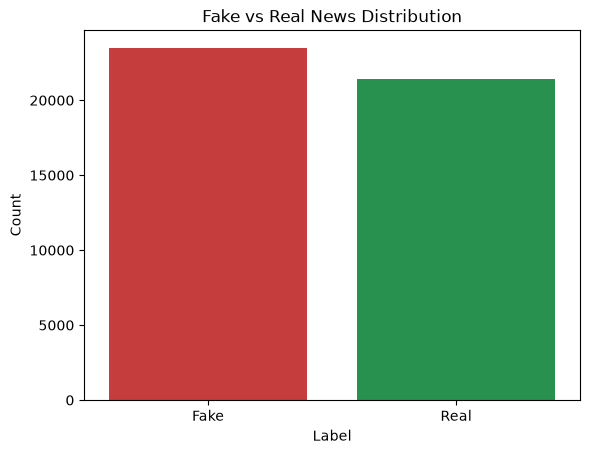

label
0    23481
1    21417
Name: count, dtype: int64


In [5]:
sns.countplot(x='label', data=df, palette=['#dc2626', '#16a34a'])
plt.xticks([0, 1], ['Fake', 'Real'])
plt.title('Fake vs Real News Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

print(df['label'].value_counts())

## 4. Text Length Analysis
Compare the average word count between fake and real news articles.

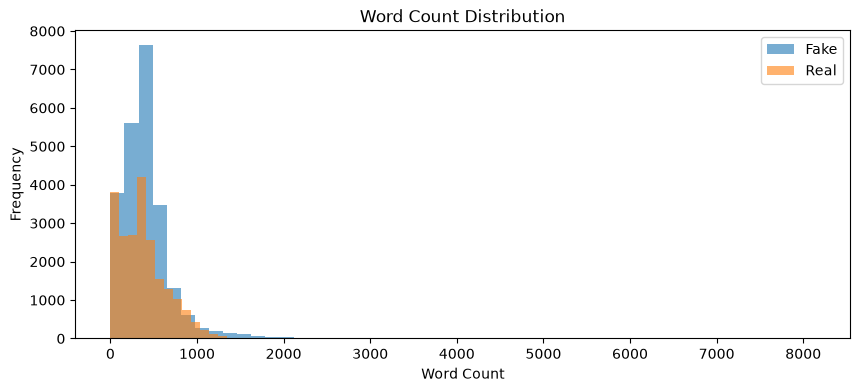

label
0    423.197905
1    385.640099
Name: text_length, dtype: float64


In [6]:
df['text_length'] = df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 4))
df.groupby('label')['text_length'].plot(kind='hist', bins=50, alpha=0.6, legend=True)
plt.legend(['Fake', 'Real'])
plt.title('Word Count Distribution')
plt.xlabel('Word Count')
plt.show()

print(df.groupby('label')['text_length'].mean())

## 5. Text Cleaning
Combine title and text, then clean using the shared utils.py function.

In [7]:
df['content'] = df['title'] + ' ' + df['text']
df['content'] = df['content'].apply(clean_text)

print("Sample cleaned text:")
print(df['content'][0][:300])

Sample cleaned text:
ben stein call th circuit court commit coup tat constitut st centuri wire say ben stein reput professor pepperdin univers also hollywood fame appear tv show film ferri bueller day made provoc statement judg jeanin pirro show recent discuss halt impos presid trump execut order travel stein refer judg


## 6. Train/Test Split & TF-IDF Vectorization
Split data 80/20 and convert text to numerical features using TF-IDF.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    df['content'], df['label'], test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

print("Train size:", X_train_vec.shape)
print("Test size: ", X_test_vec.shape)

Train size: (35918, 5000)
Test size:  (8980, 5000)


## 7. Train Logistic Regression Model
Fit a Logistic Regression classifier on the TF-IDF training features.

In [9]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

print("Training complete!")

Training complete!


## 8. Model Evaluation
Check accuracy, precision, recall and F1-score on the test set.

In [10]:
y_pred = model.predict(X_test_vec)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))

Accuracy: 0.9852

              precision    recall  f1-score   support

        Fake       0.99      0.98      0.99      4710
        Real       0.98      0.99      0.98      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



## 9. Confusion Matrix
Visualize true vs predicted labels to understand model errors.

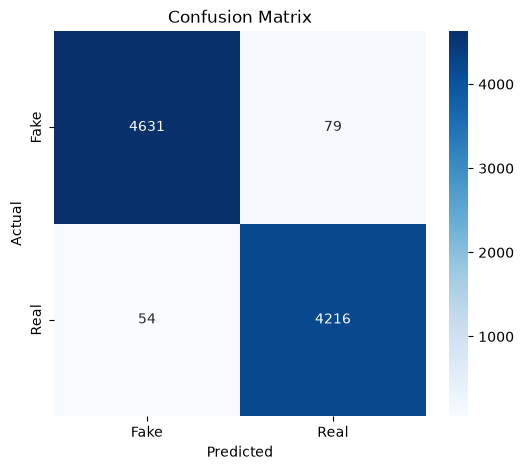

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## 10. Predict on Custom Input
Test the trained model on your own news headlines or articles.

In [12]:
def predict_news(text):
    cleaned = clean_text(text)
    vec     = vectorizer.transform([cleaned])
    pred    = model.predict(vec)[0]
    proba   = model.predict_proba(vec)[0]
    label   = "REAL ✅" if pred == 1 else "FAKE ❌"
    print(f"Prediction : {label}")
    print(f"Confidence : {round(float(max(proba)) * 100, 2)}%")

predict_news("NASA confirms water found on the moon surface")
predict_news("Government secretly replaced all birds with drones in 2001")

Prediction : FAKE ❌
Confidence : 78.29%
Prediction : FAKE ❌
Confidence : 67.73%


## 11. Save Model & Vectorizer
Export the trained model and vectorizer so app.py can load them.

In [13]:
joblib.dump(model,      '../models/model.pkl')
joblib.dump(vectorizer, '../models/vectorizer.pkl')

print("Model saved to /models ✅")

Model saved to /models ✅
